# ♻️ Organic vs Recyclable Waste Classification using CNN

This notebook builds, trains and evaluates a Convolutional Neural Network (CNN) that
classifies waste images into two categories: **Organic** and **Recyclable**.

**Pipeline**
1. Import required libraries
2. Load dataset
3. Collections count
4. Show data
5. Scale the data / check number of classes
6. Build the CNN model
7. Model summary
8. Normalization (ImageDataGenerator)
9. Train / test data generation
10. Train the model
11. Plot training accuracy
12. Plot training loss
13. Model prediction on new images

**Expected folder structure**

```
dataset/
├── TRAIN/
│   ├── O/   (organic images)
│   └── R/   (recyclable images)
└── TEST/
    ├── O/
    └── R/
```

> This structure matches the popular Kaggle "Waste Classification Data" dataset
> (22,564 training images / 2,513 test images). If you're using the sample dataset
> bundled alongside this notebook, it already follows this layout — just update
> `DATASET_DIR` below if you place the data elsewhere.

Data set Link : https://www.kaggle.com/datasets/phenomsg/waste-classification
Source: Kaggle

## Step 1: Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
import cv2
import warnings
warnings.filterwarnings('ignore')

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Activation, Dropout, Flatten, Dense, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img
from tensorflow.keras.utils import plot_model
from glob import glob

## Step 2: Load Dataset

Update `DATASET_DIR` to point at the folder that contains the `TRAIN` and `TEST`
directories (each with `O` and `R` sub-folders). By default this points at the
`dataset` folder shipped alongside this notebook.

In [15]:
DATASET_DIR = "dataset"

train_path = r"D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Train"
test_path = r"D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Test"

print("Train path:", train_path)
print("Test path :", test_path)


Train path: D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Train
Test path : D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Test


In [21]:
import os

print("TRAIN PATH:")
print(train_path)

print("\nFolders inside TRAIN:")
print(os.listdir(train_path))

print("\nFiles inside O:")
print(os.listdir(os.path.join(train_path, "O"))[:10])

print("\nFiles inside R:")
print(os.listdir(os.path.join(train_path, "R"))[:10])

TRAIN PATH:
D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Train

Folders inside TRAIN:
['O', 'R']

Files inside O:
['-bread-organic-waste-isolated-shite-background-flat-illustration_74855-14373.jpg', 'A1MBvKpOlxL._AC_UF10001000_QL80_.jpg', 'aa-Cover-74rf5oelkbaeo8j1kmiamu31v7-20171227011258.Medi.jpeg', 'ac_food_scraps_fairy_shot_3_1686.jpg', 'AdobeStock_539756104_e836ab76d05c8bfad90ac05325f1c4bf.jpeg', 'AdobeStock_550660149_428fd902f4247199467725e7eccf1673.jpeg', 'apples.png', 'Are_landfills_in_India_overloaded_from_Food_wastes.jpg', 'arina20cooking20with20scraps.jpg', 'b24fb5ba50e1c08c306afdb2ff49b1ac8a1ecd03.jpeg']

Files inside R:
['-drawing-plastic-waste-fresh-soda-drink-liquid-vector-illustration-244100830.jpg', '1574672891_p_5170256_1028237.jpeg', '210205135323-20210205-coca-cola-13-2-ounce.jpg', '230316091950-01-plastic-water-bottle-industry-climate.jpg', 'a-discarded-old-bottle-of-coca-cola-in-water-closeup-2F3417K.jpg', 'aa

In [25]:
x_data = []
y_data = []

categories = [
    os.path.join(train_path, "O"),
    os.path.join(train_path, "R")
]

valid_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

for category in categories:

    print("\nProcessing:", os.path.basename(category))

    for file in tqdm(glob.glob(os.path.join(category, "*"))):

        # Only process files
        if not os.path.isfile(file):
            continue

        # Only process image files
        if not file.lower().endswith(valid_extensions):
            continue

        # Read image
        img_array = cv2.imread(file)

        # If image cannot be read, skip it
        if img_array is None:
            print("\n⚠️ Skipping unreadable image:", file)
            continue

        # Convert BGR → RGB
        img_array = cv2.cvtColor(img_array, cv2.COLOR_BGR2RGB)

        # Resize to CNN input size
        img_array = cv2.resize(img_array, (224, 224))

        # Store image
        x_data.append(img_array)

        # Store label
        y_data.append(os.path.basename(category))

print("\n========================")
print("Dataset loading completed")
print("========================")
print("Total images:", len(x_data))
print("Classes:", set(y_data))


Processing: O


100%|████████████████████████████████████████████████████████████████████████████████| 126/126 [00:02<00:00, 51.54it/s]



Processing: R


100%|████████████████████████████████████████████████████████████████████████████████| 102/102 [00:01<00:00, 68.83it/s]


Dataset loading completed
Total images: 227
Classes: {'R', 'O'}


In [35]:
print("x_data:", len(x_data))
print("y_data:", len(y_data))

x_data: 227
y_data: 227


In [37]:
import pandas as pd

data = pd.DataFrame({
    "image": x_data,
    "label": y_data
})

print(data.shape)
print(data["label"].value_counts())
print(data["label"].unique())

(227, 2)
label
O    126
R    101
Name: count, dtype: int64
['O' 'R']


## Step 3: Collections Count

Check how many images belong to each class.

In [27]:
from collections import Counter
Counter(y_data)

Counter({'O': 126, 'R': 101})

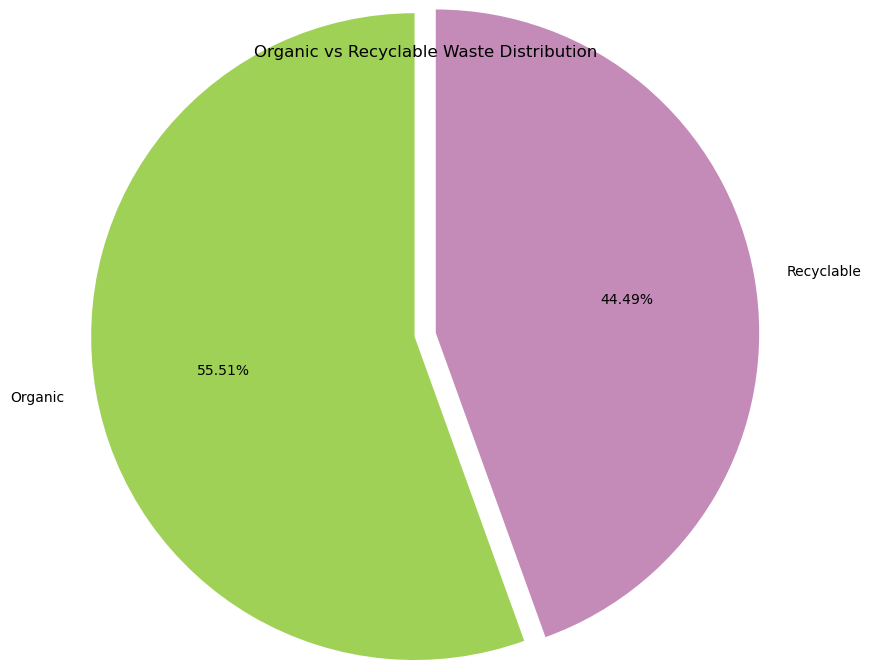

In [39]:
import matplotlib.pyplot as plt

counts = data["label"].value_counts()

label_names = {
    "O": "Organic",
    "R": "Recyclable"
}

plt.figure(figsize=(7, 7))

plt.pie(
    counts,
    startangle=90,
    explode=[0.05] * len(counts),
    autopct="%0.2f%%",
    labels=[label_names[x] for x in counts.index],
    colors=["#a0d157", "#c48bb8"],
    radius=1.5
)

plt.title("Organic vs Recyclable Waste Distribution")
plt.show()

## Step 4: Show data

Display a random sample of 9 images with their labels.

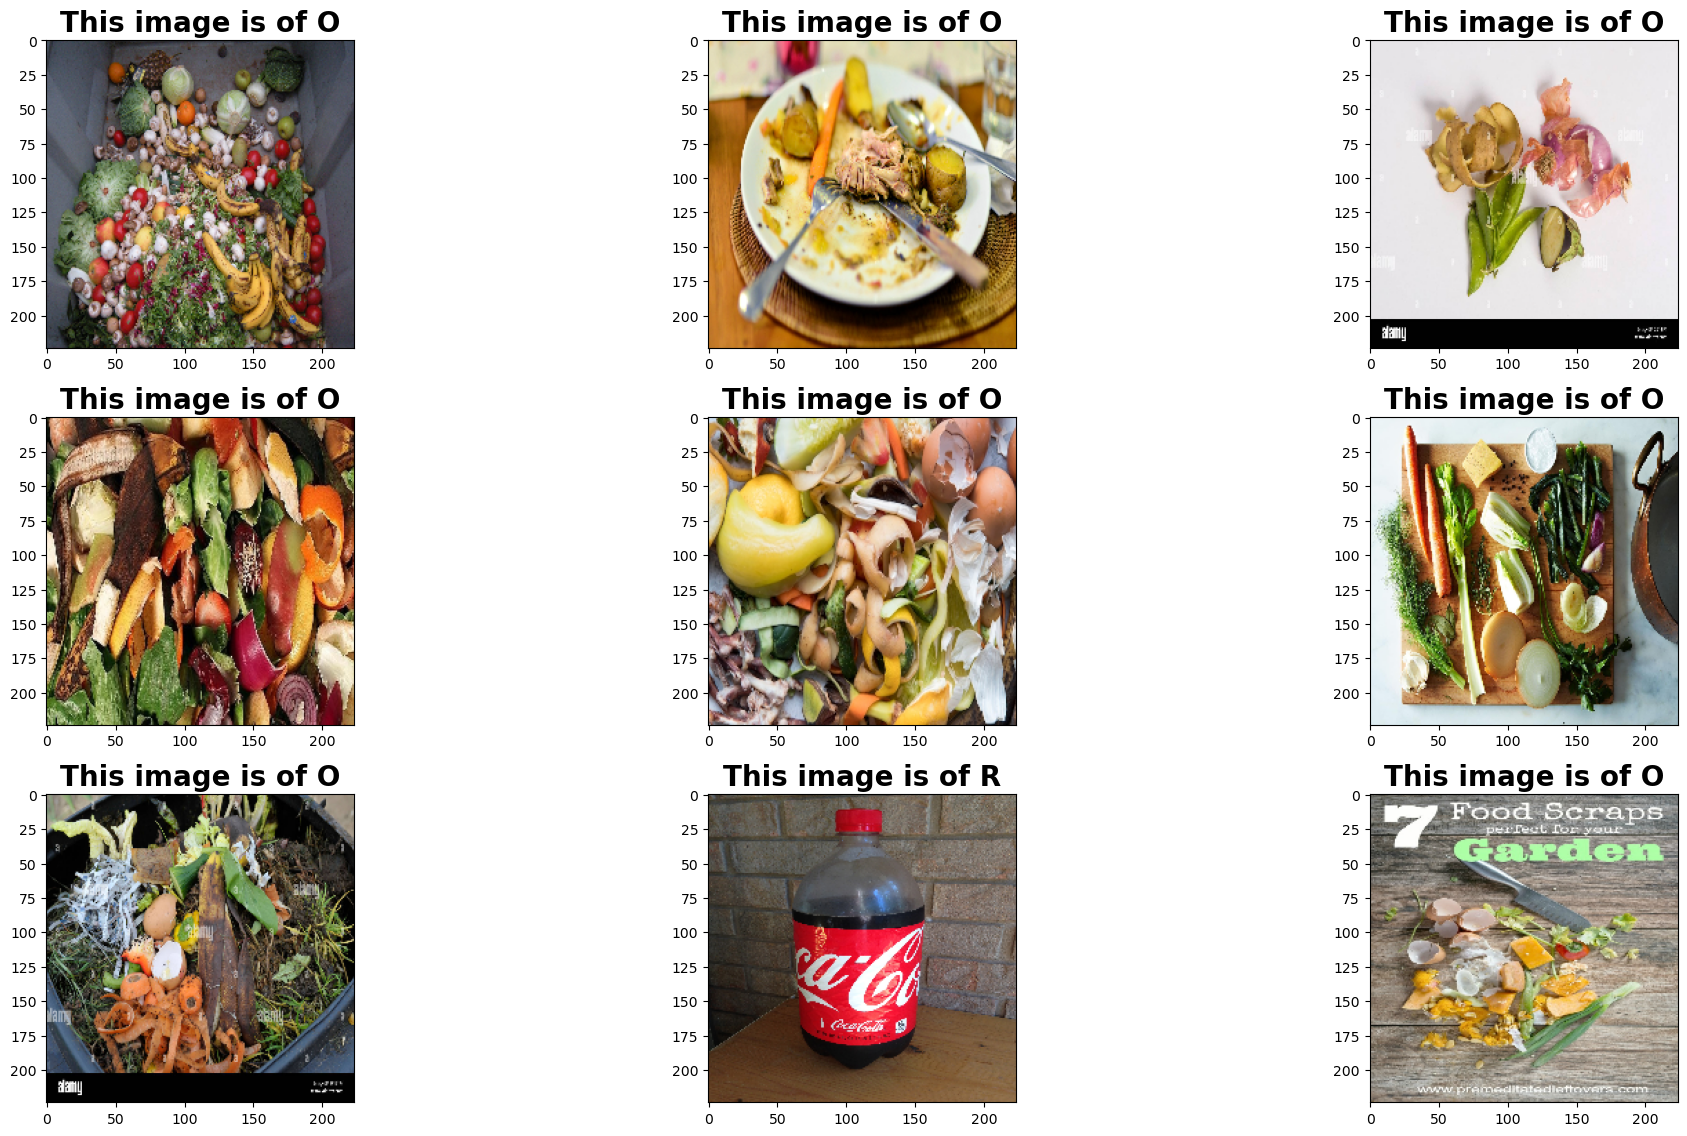

In [41]:
plt.figure(figsize=(20, 15))
for i in range(9):
    plt.subplot(4, 3, (i % 12) + 1)
    index = np.random.randint(len(data))
    plt.title('This image is of {0}'.format(data.label[index]),
              fontdict={'size': 20, 'weight': 'bold'})
    plt.imshow(data.image[index])
    plt.tight_layout()


## Step 5: Find number of classes in data

In [49]:
import glob

className = glob.glob(train_path + '/*')
numberOfClass = len(className)

print("Number Of Class:", numberOfClass)
print("Classes:", className)

Number Of Class: 2
Classes: ['D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Train\\O', 'D:/Edunet Foundation/Courses/Circuit/Module 2 - Deep Learning & Computer Vision Basics/Labs/Dataset/Train\\R']


## Step 6: Build the CNN Model

### Initialize the model

In [51]:
model = Sequential()

### Convolution, Activation and Pooling layers

In [53]:
model.add(Conv2D(32, (3, 3), input_shape=(224, 224, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(64, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())

model.add(Conv2D(128, (3, 3)))
model.add(Activation("relu"))
model.add(MaxPooling2D())


### Flatten, Dropout and output layers

In [55]:
model.add(Flatten())
model.add(Dense(256))
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(64))
model.add(Activation("relu"))
model.add(Dropout(0.5))

model.add(Dense(numberOfClass))  # output
model.add(Activation("sigmoid"))


### Compile the model

In [57]:
model.compile(loss="binary_crossentropy",
              optimizer="adam",
              metrics=["accuracy"])

batch_size = 256

## Step 7: Model Summary

In [59]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 222, 222, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 109, 109, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 52, 52, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      22,151,424 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 2)                   │             130 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 2)                   │               0 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 22,261,250 (84.92 MB)

 Trainable params: 22,261,250 (84.92 MB)

 Non-trainable params: 0 (0.00 B)

## Step 8: Normalization

Rescale pixel values from `[0, 255]` to `[0, 1]` using `ImageDataGenerator`.

In [61]:
train_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)


In [63]:
import shutil
import os

for path in [train_path, test_path]:
    checkpoint_path = os.path.join(path, ".ipynb_checkpoints")
    
    if os.path.exists(checkpoint_path):
        shutil.rmtree(checkpoint_path)
        print("Removed:", checkpoint_path)

In [65]:
print("TRAIN:")
print(os.listdir(train_path))

print("\nTEST:")
print(os.listdir(test_path))

TRAIN:
['O', 'R']

TEST:
['O', 'R']


## Step 9: Train and Test data generation

In [67]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 227 images belonging to 2 classes.
Found 40 images belonging to 2 classes.


In [69]:
print(train_generator.class_indices)
print(test_generator.class_indices)

{'O': 0, 'R': 1}
{'O': 0, 'R': 1}


## Step 10: Train the Model

Trains for 10 epochs by default — increase `epochs` for better accuracy if you have
the time/compute.

In [73]:
hist = model.fit(
    train_generator,        # Pass the generator directly
    epochs=10,
    validation_data=test_generator   # Validation data generator
)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 18s 1s/step - accuracy: 0.5152 - loss: 1.0067 - val_accuracy: 0.7750 - val_loss: 0.6878
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 789ms/step - accuracy: 0.5882 - loss: 0.6807 - val_accuracy: 0.7000 - val_loss: 0.6669
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 814ms/step - accuracy: 0.6605 - loss: 0.6464 - val_accuracy: 0.7500 - val_loss: 0.5978
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 814ms/step - accuracy: 0.7007 - loss: 0.6110 - val_accuracy: 0.8500 - val_loss: 0.5512
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 785ms/step - accuracy: 0.6887 - loss: 0.6394 - val_accuracy: 0.8250 - val_loss: 0.5427
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 783ms/step - accuracy: 0.7393 - loss: 0.5494 - val_accuracy: 0.7750 - val_loss: 0.5981
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 783ms/step - accuracy: 0.8362 - loss: 0.5530 - val_accuracy: 0.8250 - val_loss: 0.5403
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 13s 788ms/step - accuracy: 0.8398 - loss: 0.4242 - val_accuracy: 0.8000 - val_

In [75]:
# Save the trained model so it can be loaded later (e.g. by the Streamlit app)
model.save("waste_classifier_model.h5")
print("Model saved to waste_classifier_model.h5")

Model saved to waste_classifier_model.h5


## Step 11: Plot Training Accuracy

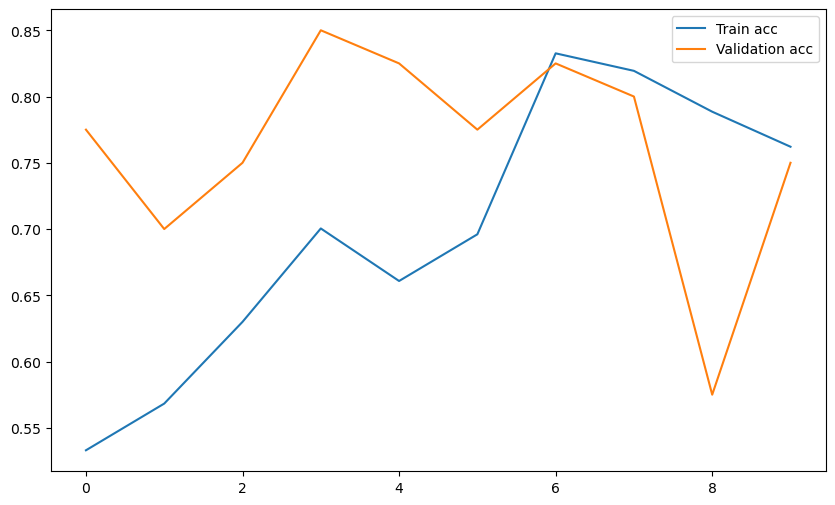

In [77]:
plt.figure(figsize=[10, 6])
plt.plot(hist.history["accuracy"], label="Train acc")
plt.plot(hist.history["val_accuracy"], label="Validation acc")
plt.legend()
plt.show()

## Step 12: Plot Loss

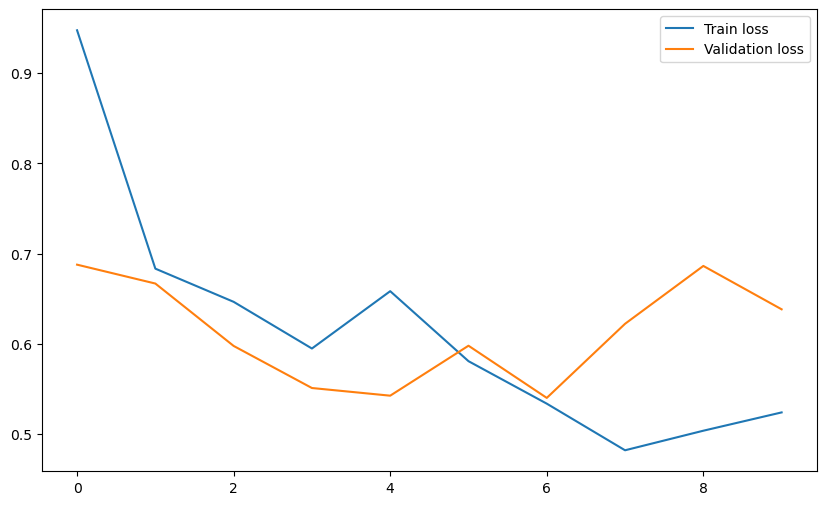

In [79]:
plt.figure(figsize=(10, 6))
plt.plot(hist.history['loss'], label="Train loss")
plt.plot(hist.history['val_loss'], label="Validation loss")
plt.legend()
plt.show()

## Step 13: Model Prediction

`class_indices` from the generator tells us which folder was mapped to which index
(alphabetical order: `O` → 0, `R` → 1). We use that mapping in `predict_func` so the
label is always correct regardless of folder order.

In [81]:
print(train_generator.class_indices)

{'O': 0, 'R': 1}


In [83]:
# Build an index -> label map directly from the generator so this always matches
# however the folders were named/ordered.
idx_to_label = {v: k for k, v in train_generator.class_indices.items()}
label_names = {"O": "Organic", "R": "Recyclable"}

def predict_func(img):
    plt.figure(figsize=(6, 4))
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.tight_layout()
    plt.show()

    resized = cv2.resize(img, (224, 224))
    resized = np.reshape(resized, [-1, 224, 224, 3]) / 255.0
    result = np.argmax(model.predict(resized))

    folder = idx_to_label[result]
    label = label_names.get(folder, folder)
    print(f"This image -> {label}")
    return label


In [ ]:
# Example usage (update the path to an image in your TEST folder):
# test_img = cv2.imread(f"{test_path}/O/O_12573.jpg")
# predict_func(test_img)


In [ ]:
# Example usage for the other class:
# test_img = cv2.imread(f"{test_path}/R/R_10753.jpg")
# predict_func(test_img)


---
## Next steps

- Try more epochs, data augmentation (rotation/zoom/flip in `ImageDataGenerator`), or
  a pretrained backbone (transfer learning with e.g. MobileNetV2) for higher accuracy.
- Once you're happy with the model, run the accompanying **`app.py`** Streamlit app to
  classify new images through a simple web UI:

```bash
streamlit run app.py
```
